# Import Libraries and Define Project Folders

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120

# Load Data

In [2]:
df = pd.read_csv(
    DATA_DIR / "cbsd_main_2022_02.csv",
    dtype={"start_station_id": "string", "end_station_id": "string"},
    low_memory=False
)

# parse dates safely (errors='coerce' prevents crashes if any weird rows exist)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"] = pd.to_datetime(df["ended_at"], errors="coerce")

df.shape

(29838166, 15)

In [3]:
daily = pd.read_csv(DATA_DIR / "cbsd_daily_2022_01.csv", parse_dates=["date"])
daily = daily.sort_values("date").set_index("date")

daily.shape

(365, 2)

## Create month and season variables
The original trip-level dataset included a `date` field but did not include `month` or `season`. I converted `date` to datetime format, extracted the month number, and created a season category so the station analysis could support seasonal filtering in the dashboard.

In [4]:
df["month"] = df["date"].dt.month

In [5]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(month_to_season)

In [6]:
df[["date", "month", "season", "start_station_name"]].head()

,date,month,season,start_station_name
0,2022-01-21,1,Winter,West End Ave & W 107 St
1,2022-01-10,1,Winter,4 Ave & 3 St
2,2022-01-26,1,Winter,1 Ave & E 62 St
3,2022-01-03,1,Winter,2 Ave & E 96 St
4,2022-01-22,1,Winter,6 Ave & W 34 St


In [7]:
df["season"].value_counts()

season
Summer    10318049
Fall       8734218
Spring     6972675
Winter     3813224
Name: count, dtype: int64

In [8]:
station_trip_cols = ["date", "month", "season", "start_station_name"]

stations_df = df[station_trip_cols].copy()

stations_df.head()

,date,month,season,start_station_name
0,2022-01-21,1,Winter,West End Ave & W 107 St
1,2022-01-10,1,Winter,4 Ave & 3 St
2,2022-01-26,1,Winter,1 Ave & E 62 St
3,2022-01-03,1,Winter,2 Ave & E 96 St
4,2022-01-22,1,Winter,6 Ave & W 34 St


In [9]:
stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29838166 entries, 0 to 29838165
Data columns (total 4 columns):
 #   Column              Dtype         
---  ------              -----         
 0   date                datetime64[ns]
 1   month               int32         
 2   season              object        
 3   start_station_name  object        
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 796.8+ MB


## Create a reduced station-analysis dataframe
I created a smaller dataframe containing only the columns needed for the stations page of the dashboard: `date`, `month`, `season`, and `start_station_name`. This reduces file size and keeps the Streamlit app focused on only the fields required for seasonal station analysis.

In [20]:
np.random.seed(32)
keep_mask = np.random.rand(len(stations_df)) <= 0.02

stations_sample = stations_df[keep_mask].copy()

stations_sample.shape

(597418, 4)

In [21]:
stations_sample.head()

,date,month,season,start_station_name
53,2022-01-16,1,Winter,Broadway & Berry St
63,2022-01-25,1,Winter,S 4 St & Wythe Ave
142,2022-01-11,1,Winter,E 2 St & 2 Ave
148,2022-01-27,1,Winter,Cleveland Pl & Spring St
153,2022-01-22,1,Winter,Cleveland Pl & Spring St


In [22]:
stations_sample["season"].value_counts(dropna=False)

season
Summer    206179
Fall      174951
Spring    139786
Winter     76502
Name: count, dtype: int64

## Create a reproducible sample for deployment
I created an 8% random sample of the reduced station-analysis dataframe using a fixed random seed (`32`). This keeps the dataset small enough for deployment while preserving the underlying seasonal and station-level patterns needed for the dashboard.

In [23]:
# Export new CSV
stations_sample.to_csv("../data/cbsd_station_trips_sample.csv", index=False)

## Final reduced trip-level sample
I initially tested a larger sample, but the resulting CSV was still too large for a simple GitHub-based deployment workflow. I reduced the random sample to 2%, using a fixed seed of 32, which produced a file under the file-size limit while still preserving enough trip-level data to support seasonal station filtering in the dashboard.

# Top 20 most popular START stations

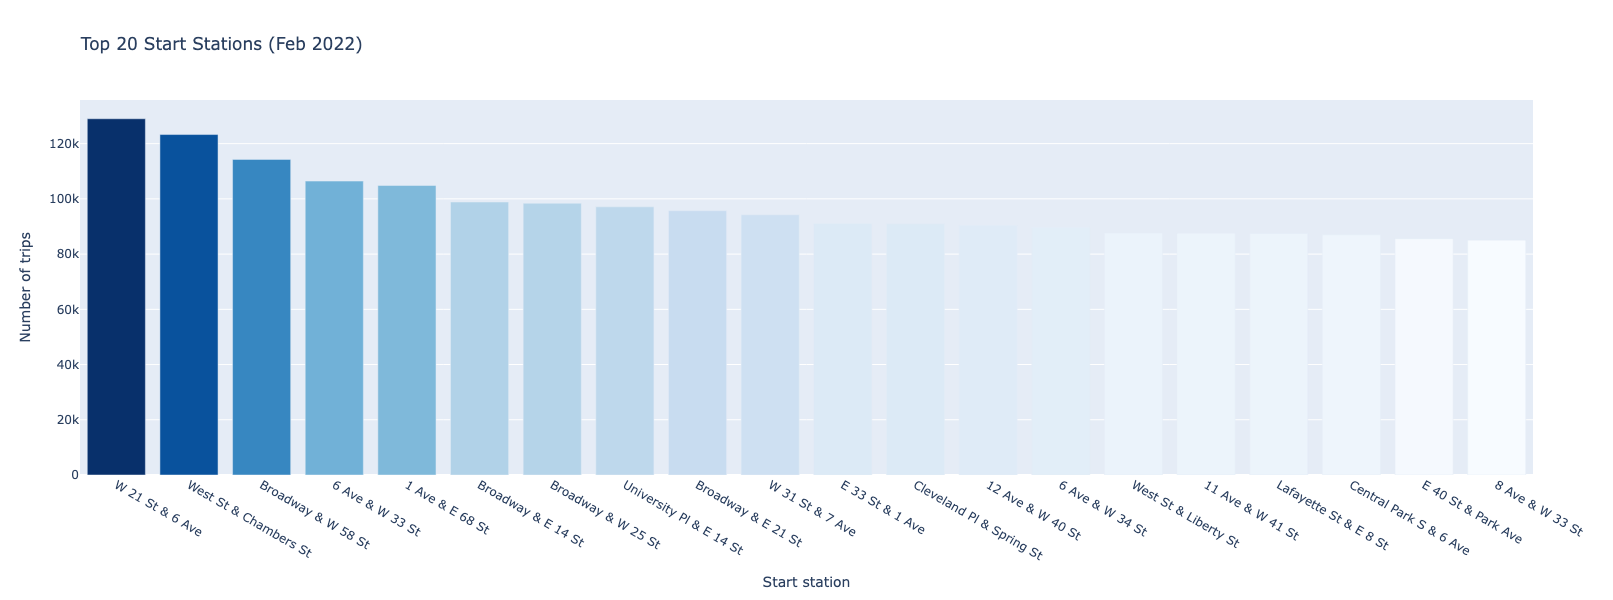

PosixPath('../outputs/top20_start_stations_2022_02.csv')

In [6]:
# Top 20 most popular START stations
df["value"] = 1
df_group = df.groupby("start_station_name", as_index=False).agg({"value": "sum"})
top20 = df_group.nlargest(20, "value").sort_values("value", ascending=False)

# Save for later dashboard use
top20_path = OUTPUTS_DIR / "top20_start_stations_2022_02.csv"
top20.to_csv(top20_path, index=False)

# Plotly bar chart
fig = go.Figure(
    go.Bar(
        x=top20["start_station_name"],
        y=top20["value"],
        marker={"color": top20["value"], "colorscale": "Blues"},
    )
)

fig.update_layout(
    title="Top 20 Start Stations (Feb 2022)",
    xaxis_title="Start station",
    yaxis_title="Number of trips",
    width=950,
    height=600,
)

fig.show()

top20_path

# Dual Axis Line Chart for aggregated bike trips and temperature in plotly

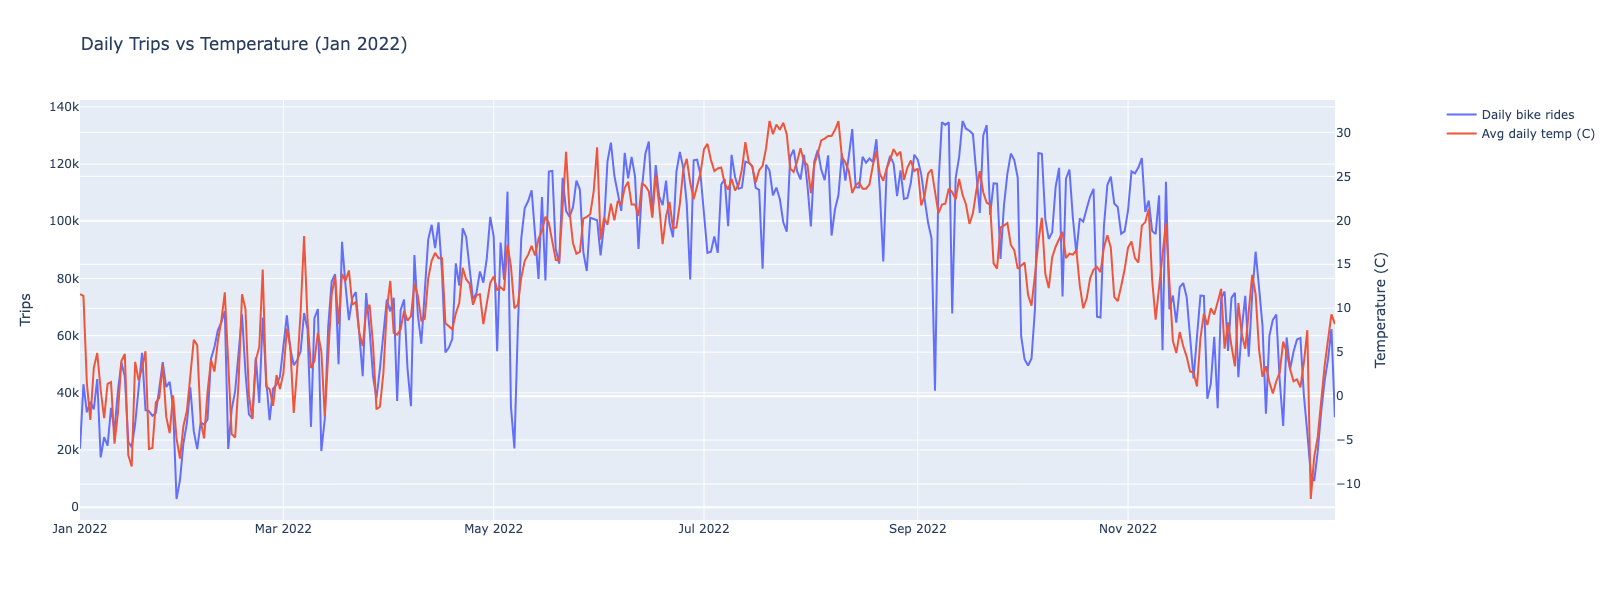

In [5]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig2 = make_subplots(specs=[[{"secondary_y": True}]])

# Trips on left axis
fig2.add_trace(
    go.Scatter(
        x=daily.index,
        y=daily["bike_rides_daily"],
        name="Daily bike rides",
        mode="lines",
    ),
    secondary_y=False,
)

# Temperature on right axis
fig2.add_trace(
    go.Scatter(
        x=daily.index,
        y=daily["tavg_c"],
        name="Avg daily temp (C)",
        mode="lines",
    ),
    secondary_y=True,
)

fig2.update_layout(
    title="Daily Trips vs Temperature (Jan 2022)",
    height=600,
)

fig2.update_yaxes(title_text="Trips", secondary_y=False)
fig2.update_yaxes(title_text="Temperature (C)", secondary_y=True)

fig2.show()

# Dashboard dataset export (for Streamlit)
- Streamlit scripts run top-to-bottom on every refresh. Heavy wrangling inside the .py file slows the app and can make it feel laggy.
- Here, I export a lightweight, “ready-to-plot” CSV that includes only the columns the dashboard needs.
- This mirrors a common production pattern: do transformations once in a notebook, save clean outputs, and load them quickly in the app.

In [6]:
# 1) Ensure we have a clean daily dataframe with explicit columns
dash_daily = daily.copy()

# 2) Create a proper 'date' column (Streamlit/Plotly can use either index or column,
#    but a column is often simpler when you later filter or merge)
dash_daily = dash_daily.reset_index().rename(columns={"index": "date"})

# 3) Add month and season columns (useful later for dashboard filters)
dash_daily["month"] = dash_daily["date"].dt.month.astype(int)

dash_daily["season"] = np.select(
    [
        (dash_daily["month"] == 12) | (dash_daily["month"].between(1, 3)),
        (dash_daily["month"].between(4, 5)),
        (dash_daily["month"].between(6, 9)),
        (dash_daily["month"].between(10, 11)),
    ],
    ["winter", "spring", "summer", "fall"],
    default="unknown",
)

# 4) Keep only what the dashboard needs (faster load + less confusion)
dash_daily = dash_daily[["date", "bike_rides_daily", "tavg_c", "month", "season"]]

# 5) Export to data/
data_path = DATA_DIR / "cbsd_daily_dashboard_2022_01.csv"
dash_daily.to_csv(data_path, index=False)

data_path, dash_daily.head()

(PosixPath('../data/cbsd_daily_dashboard_2022_01.csv'),
         date  bike_rides_daily  tavg_c  month  season
 0 2022-01-01             20428    11.6      1  winter
 1 2022-01-02             43009    11.4      1  winter
 2 2022-01-03             33189     1.4      1  winter
 3 2022-01-04             36842    -2.7      1  winter
 4 2022-01-05             34230     3.2      1  winter)